# T-Maze Active Inference — Planning as Message Passing

This notebook provides the code for the Paper "Parameter Learning in Discrete Active Inference via Message-Passing". 

It extends previous work on Planning as Inference via Expected Free Energy minimization to parameter learning in discrete state-spaces (POMDPs). It implements an Active Inference agent that navigates a T-maze by minimising **Expected Free Energy (EFE)** via variational message passing in [RxInfer.jl](https://github.com/ReactiveBayes/RxInfer.jl).

It is the notebook to the current Short Technical Communication. 

It builds on two **key references**:
- Paper 1: [*EFE-based Planning as Variational Inference*](https://arxiv.org/abs/2504.14898) (de Vries et al., 2025) — the foundational theorem.  
- Paper 2: [*A Message Passing Realization of EFE Minimization*](https://arxiv.org/abs/2508.02197) (Nuijten et al., 2025) — the practical message-passing algorithm validated here.

## 1 · Setup and the T-Maze Problem

### 1.1 Package imports

In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `c:\Users\BMW\Documents\activeInference\rxinfer\EFEasVI_parameters`


In [2]:
using RxInfer, Distributions, Plots, LinearAlgebra, Random, StableRNGs, ColorSchemes, Tullio
using LogExpFunctions: softmax, xlogx, xlogy, logsumexp
using SpecialFunctions: digamma

### 1.2 The T-maze task

The agent starts at the center of the T-trunk and must reach the rewarded arm (left or right). It faces two challenges:

- **Partial observability** — reward location is hidden; a cue is only visible at the trunk bottom.
- **Exploration–exploitation** — the agent must decide whether to read the cue first or head directly for an arm.

The agent has four actions: North (1), East (2), South (3), West (4) to naviagate in the T-Maze consisting of 5 fields.

Here is a visualization, where the agent is marked as a blue dot.

Additionally to the complexity, we add complexity where the agent starts with 0 knowledge about the state transitions and observation likelihood. To succeed it needs to do efficient parameter learning. 

<div align="center"><img src="T-Maze.png" width="200"></div>

We set up the necessary structures in julia:

In [6]:
Base.@kwdef mutable struct TMaze
    agent_position::Tuple{Int,Int}
    reward_position::Symbol
    reward_values::Dict{Tuple{Int,Int},Float64}
end

const STATE_TO_POS = ((2, 1), (2, 2), (1, 3), (2, 3), (3, 3))
const POS_TO_STATE = Dict((2, 1) => 1, (2, 2) => 2, (1, 3) => 3, (2, 3) => 4, (3, 3) => 5)

function create_tmaze(reward_position::Symbol, start_position::Tuple{Int,Int})
    reward_position in (:left, :right) || throw(ArgumentError("reward_position must be :left or :right"))
    haskey(POS_TO_STATE, start_position) || throw(ArgumentError("Invalid start position. Must be one of: $(collect(STATE_TO_POS))"))
    s = reward_position == :left ? 1.0 : -1.0
    reward_values = Dict((1, 3) => s, (3, 3) => -s)
    return TMaze(agent_position = start_position, reward_position = reward_position, reward_values = reward_values)
end

const ACTION_NAMES = ("North", "East", "South", "West")
@enum Direction::UInt8 North=1 East=2 South=3 West=4
action_to_string(i::Integer) = (1 <= i <= 4) ? ACTION_NAMES[i] : "Unknown"

# Deterministic dynamics: NEXT_STATE[current_state, action_idx] -> next_state
# action_idx: 1=North, 2=East, 3=South, 4=West
const NEXT_STATE = [
    2 1 1 1;
    4 2 1 2;
    3 4 3 3;
    4 5 2 3;
    5 5 5 4;
]

Base.@kwdef mutable struct TMazeBeliefs
    location::Categorical{Float64}
    reward_location::Categorical{Float64}
    action_posterior::Categorical{Float64}
end

initialize_beliefs_tmaze() = TMazeBeliefs(
    location         = Categorical([0.0,1.0,0.0,0.0,0.0]), # agent knows where it starts #Categorical(fill(1.0 / 5, 5)),
    reward_location  = Categorical([0.5, 0.5]),
    action_posterior = Categorical(fill(0.25, 4))
)

initialize_beliefs_tmaze (generic function with 1 method)

## 2 · Theory: EFE as VI

### 2.1 The Expected Free Energy Cost Function

Before writing any model code it is worth understanding *what* the agent is trying to minimise.

For a candidate policy $u$, the **Expected Free Energy** $G(u)$ can be decomposed to a form with preferences over states, defined as:

$$
G(u_t) = \underbrace{\mathbb{E}_{q(x_t|u_t)}[\mathrm{H}[p(y_t|x_t)]]}_{\text{Ambiguity}} + \underbrace{D_{KL}[q(x_t|u_t)||\hat{p}(x_t)]}_{\text{Risk (states)}} - \underbrace{\mathbb{E}_{p(y_t|x_t)q(x_t|u_t)}[D_{KL}[q(\theta|y_t, x_t, u_t)||q(\theta)]]}_{\text{Novelty}}
$$

This decomposition shows that the cost function is composed of three primary drivers: risk, which measures the divergence between predicted outcomes and preferred states $\hat{p}(x)$ to keep the agent goal-oriented,  ambiguity, which calculates the expected uncertainty of future observations to encourage states with clear, informative data and novelty, which pushes the agent to explore states that maximise the updates of its current beliefs about its parameters. By minimizing $G(u)$, the agent naturally balances these terms to produce behavior that is simultaneously goal-directed and information-seeking — offering a principled solution to the classic exploration–exploitation trade-off.

> **T-maze reading**: without the cue, the reward location is highly uncertain. The agent's epistemic drive pushes it to the cue location first; once the cue is read, risk dominates and the agent heads for the correct arm.

### 2.2 · EFE as Variational Inference — The Key Theorem

#### 2.2.1 Why the Tree Search approach fails

A naive implementation evaluates $G(u_t)$ for every candidate policy sequence. For a planning horizon $T$ and $|\mathcal{U}|$ actions, this requires $|\mathcal{U}|^T$ evaluations — intractable for any non-trivial horizon.



#### 2.2.2 Planning as Variational Inference

The central insight of [Paper 1 (Theorem 1)](https://arxiv.org/pdf/2504.14898#Theorem.1) is that EFE minimisation *arises naturally* from minimising a standard **Variational Free Energy (VFE)** functional if we *augment* the generative model with few prior terms:

$$
\mathcal{F}[q] \;\triangleq\;
\mathbb{E}_{q(y,x,θ,u)}\!\left[
  \log\frac{q(y,x,θ,u)}{p(y,x,θ,u)\;\hat{p}(x)\;\tilde{p}(u)\;\tilde{p}(x)}
\right]
$$

The denominator is the ordinary generative model $p$ *augmented* by:
- a **preference prior** $\hat{p}(x)$ over desired future states, and
- two **epistemic priors** $\tilde{p}(u),\tilde{p}(x)$ that encode ambiguity-avoidance and novelty-seeking drives.

Previous work \cite{nuijten2026messagepassingrealizationexpected} has successfully implemented this for hidden-state approximation, but missed the possibility of parameter learning. 

The current paper/Short Technical Communication meets this challenge and extends the implementation of the theoretical theorem of paper \cite{devries2025expectedfreeenergybasedplanning} and previous implementation to parameter learning in discrete state spaces in a POMDP.

 
**Corrolary 1** states that with the specific choices

$$
\tilde{p}(u)\propto \exp( \mathbb{E}_{q(\boldsymbol{x}|\boldsymbol{u})}\left[-\log q(\boldsymbol{x}|\boldsymbol{u}) + D_{KL}(q(\theta_B|\boldsymbol{x},\boldsymbol{u}) \parallel q(\theta_B)) \right]) \\
\tilde{p}(x) \propto \exp( \mathbb{E}_{q(\boldsymbol{y}|\boldsymbol{x})} \left[ \log q(\boldsymbol{y}| \boldsymbol{x}) + D_{KL}(q(\theta_A|\boldsymbol{y}, \boldsymbol{x}) \parallel  q(\theta_A))   \right])
$$

the VFE decomposes exactly as

$$
\boxed{\mathcal{F}[q] \;=\; \mathbb{E}_{q(u)}[G(u)] \;+\; \underbrace{\mathbb{E}_{q(y,x,θ,u)}\!\left[\log\tfrac{q(y,x,θ|u)}{p(y,x,θ|u)}\right]}_{\text{complexity } C(u)}\;+\; const.}
$$

**What this buys us**: minimising $\mathcal{F}[q]$ over the variational posterior $q$ simultaneously

1. reduces the *expected* EFE over policies, and
2. keeps the posterior close to the Bayesian ideal (bounded-rationality term $C(u)$).

Because $\mathcal{F}[q]$ is a standard VFE, *any* off-the-shelf variational inference algorithm — including reactive message passing on a factor graph — can be used to minimise it. The combinatorial search is gone.

Importantly, especially with regard to previous attempts \cite{nuijten2025activeinferencesubtypevariational} the derived epistemic factors allow for implementation on a standard factor graph model with single beliefs per edge.

#### 2.2.3 Why message passing works here

Factor graphs factorise $p(y,x,u, \theta)$ into local factors. Variational message passing finds stationary points of the *Bethe free energy*, which approximates the VFE. Because $\mathcal{F}[q]$ decomposes into local contributions, each node in the graph can run its own local update — and the global EFE is minimised as a side-effect.

### 2.3 · Epistemic Priors — Factorised Form for State-Space Models

Theorem 1 defined the priors in terms of global quantities $H[q(x|u)]$ and $H[q(y|x)]$. To take advantage of local computations, we **factorize** the state-space model into

$$
p(y,x,u, \theta) \;=\; p(x_0) p(\theta) \prod_{t=1}^{T} p(y_t|x_t,\theta_A)\,p(x_t|x_{t-1},u_t,\theta_B)\,p(u_t)
$$

With this factorized SSM **Corollary 1** of the current paper reduces the priors to *per-timestep, local* expressions:

$$
\tilde{p}(u_t) \propto \exp( \mathbb{E}_{q(x_t, x_{t-1}|u_t)}\left[-\log q(x_t|x_{t-1},u_t) + D_{KL}(q(\theta_B|x_t, x_{t-1}, u_t) \parallel q(\theta_B)) \right]) \\
\tilde{p}(x_t) \propto \exp( \mathbb{E}_{q(y_t|x_t)} \left[ \log q(y_t | x_t) + D_{KL}(q(\theta_A|y_t, x_t) \parallel  q(\theta_A))   \right])
$$

These are exactly the two prior nodes we add to the factor graph:

| Node | Prior | Intuition |
|------|-------|-----------|
| **Exploration & Transition Learning** (action prior) | $\tilde{p}(u_t)$ — conditional entropy of the transition | favours actions that lead to uncertain future states, and increase belief updates regarding the B tensor → risk seeking + novelty seeking |
| **Ambiguity avoidance & Likelihood Learning** (state prior) | $\tilde{p}(x_t)$ — negative entropy of the observation | favours states where observations aren't noisy and states that increase belief updates regarding the A tensor → ambiguity reducing + novelty seeking |

#### 2.3.1 Circular dependency and its resolution

As mentioned by previous implementations \cite{nuijten2026messagepassingrealizationexpected}, there is a subtlety: the priors at iteration $\tau$ depend on the posteriors $q_{\tau-1}$ from the *previous* iteration. We can resolve this circularity iteratively by initialising $q_0$ uniformly, and then alternating between

1. Computing $\tilde{p}_\tau$ from previous VMP iteration $q_{\tau-1}$.
2. Running one full round of message passing to get $q_\tau$.

This approach, while solving the issue of interdependencies, incorporates a limitation: Convergence is empirically observed even though it is not guaranteed in general.

## 3 · The Augmented Factor-Graph Model

Now let's head back to our challenge. We start by drawing the graph of the generative model. The figure below illustrates the augmented Forney-style factor graph for the T-maze agent, unfolded from the current state through a planning horizon ($t = 1 \dots T$).  
The original generative model (transition and observation factors) is shown in white; the two added epistemic prior nodes are shown in red (Exploration) and green (Ambiguity) whereas the preference prior in blue.

![](FFG-tmaze.svg)

Each timeslice $t$ contains:
- $f_B = p(x_t | x_{t-1}, u_t)$ — deterministic location transition.
- $f_A = p(y_t | x_t, rew)$ — observation factor (reward cue depends on reward location $rew$).
- $\tilde{p}(u_t)$ — **Exploration & Transition Novelty** epistemic prior on the action.
- $\tilde{p}(x_t)$ — **Ambiguity & Likelihoo Novelty** epistemic prior on the state.
- $\hat{p}(x_t)$ — preference prior (only at the terminal step, encoding the desired goal state).

The orange directed edges in the diagram indicate the local joint beliefs from the previous VMP iteration $q_{\tau-1}$ computed at the transition and observation nodes send towards the epistemic prior nodes.

In RxInfer we can write this the following:

In [7]:
@model function efe_tmaze_agent(p_A, p_B, m_A, m_B, prior_location, prior_reward_location, reward_to_location_mapping, u_prev, T, reward_cue_observation, location_observation)
    old_location ~ Categorical(prior_location)
    reward_location ~ Categorical(prior_reward_location)

    reward_observation_tensor  ~ p_A # DirichletCollection(ones(2, 5, 2))
    location_transition_tensor ~ p_B # DirichletCollection(ones(5, 5, 4))

    current_location ~ DiscreteTransition(old_location, location_transition_tensor, u_prev)
    location_observation ~ DiscreteTransition(current_location, diageye(5))
    reward_cue_observation ~ DiscreteTransition(current_location, reward_observation_tensor, reward_location)

    previous_location = current_location
    for t in 1:T
        # Step 1 — allocate storage for q_{τ-1} (Bethe beliefs from previous VFE iteration)
        loc_marginalstorage = JointMarginalStorage(Contingency(ones(size(p_B.α))), :location_marginal, t)
        observation_marginalstorage = JointMarginalStorage(Contingency(ones(size(p_A.α))), :observation_marginal, t)

        # Step 2 — Exploration prior p̃(u_t): computed from stored transition beliefs from previous VMP
        u[t] ~ Exploration(reward_cue_observation, p_B.α) where {meta=loc_marginalstorage}
        #u[t] ~ Categorical(fill(0.25, 4))  # KL-Control prior

        # Step 3 — State transition; joint belief q(x_t, x_{t-1}, u_t) is saved into loc_marginalstorage
        location[t] ~ DiscreteTransition(previous_location, m_B, u[t]) where {meta=loc_marginalstorage}

        # Step 4 — Simulate future observation; joint q(y_t, x_t) is saved into observation_marginalstorage
        future_rew_cue_obs[t] ~ DiscreteTransition(location[t], m_A, reward_location) where {meta=observation_marginalstorage}
        future_rew_cue_obs[t] ~ Categorical([0.5, 0.5])  # closes the half-edge on the factor graph

        # Step 5 — Ambiguity prior p̃(x_t): computed from stored observation beliefs from previous VMP
        location[t] ~ Ambiguity(reward_cue_observation, p_A.α) where {meta=observation_marginalstorage}

        previous_location = location[t]
    end
    location[end] ~ DiscreteTransition(reward_location, reward_to_location_mapping)
end

## 4 · Implementation of epistemic priors

Looking at this model we see a few curiosities. 

### 4.1 `JointMarginalComponent` — saving Bethe beliefs between iterations

A few nodes have an extra meta attribute. 

We remember that the epistemic priors at iteration $\tau$ require the joint posteriors $q_{\tau-1}(x_t, x_{t-1}, u_t)$ and $q_{\tau-1}(y_t, x_t)$ from the *previous* message-passing sweep.  
Therefor we create a mutable container that RxInfer's marginal rules can write into:

In [8]:
mutable struct JointMarginalStorage{C}
    joint_marginal::C
    name::Symbol # :location_marginal or :observation_marginal
    index::Int   # timestep t
end

function set_marginal!(jmm::JointMarginalStorage{C}, marginal) where {C}
    jmm.joint_marginal = marginal
    return jmm
end

set_marginal! (generic function with 1 method)

### 4.2 Custom `@marginalrule` — intercepting the joint beliefs

On a factor graph, the Bethe beliefs around a factor node $f$ are calculated as a product of the factor function and the incoming messages.
For $f(x_t, x_{t-1}, u_t)$ this means:

$$q(x_t, x_{t-1}, u_t) \;\propto\; f_B(x_t, x_{t-1}, u_t)\; m_{x_t \to f}(x_t)\; m_{x_{t-1} \to f}(x_{t-1})\; m_{u_t \to f}(u_t)$$

In RxInfer we can intercept this computation via a custom `@marginalrule` that calls the built-in rule, and then stores the result in the previously created JointMarginalStorage:

In [10]:
@marginalrule DiscreteTransition(:out_in_T1) (m_out::Categorical,
                                              m_in::Categorical,
                                              m_T1::Categorical,
                                              q_a::PointMass{<:AbstractArray{T,3}},
                                              meta::Any) where {T} = begin
    @tullio result[a, b, c] := q_a.point[a, b, c] * probvec(m_out)[a] * probvec(m_in)[b] * probvec(m_T1)[c]
    normalize!(result, 1)
    return Contingency(result, Val(false))
end

In [11]:
@marginalrule DiscreteTransition(:out_in_T1) (m_out::Categorical,
                                              m_in::Categorical,
                                              m_T1::Categorical,
                                              q_a::PointMass{<:AbstractArray{T,3}},
                                              meta::JointMarginalStorage) where {T} = begin
    marginal = @call_marginalrule DiscreteTransition(:out_in_T1) (m_out=m_out, m_in=m_in, m_T1=m_T1, q_a=q_a, meta=nothing)
    set_marginal!(meta, marginal)
    return marginal
end

### 4.3 `Exploration` node — the action epistemic prior $\tilde{p}(u_t)$

The action prior is derived as:

$\tilde{p}(u_t) \propto \exp( \mathbb{E}_{q(x_t, x_{t-1}|u_t)}\left[-\log q(x_t|x_{t-1},u_t) + D_{KL}(q(\theta_B|x_t, x_{t-1}, u_t) \parallel q(\theta_B)) \right])$

To handle the updating of these parameters easily we define a custom factor node and a `rule` that implements this computation.

To make use of optimized log-function calculations in julia we calculate this conditional entropy in its decomposed form as: $$H_q(\mathbf{x}_t \mid \mathbf{x}_{t-1}, u_t) = -\sum_{x_t, x_{t-1}} \Big[ q(x_t, x_{t-1} \mid u_t) \log q(x_t, x_{t-1} \mid u_t) - q(x_t, x_{t-1} \mid u_t) \log q(x_{t-1} \mid u_t) \Big]$$ 

Further, the parameter novelty term $D_{KL}(q(\theta_B|x_t, x_{t-1}, u_t) \parallel q(\theta_B))$ represents the information gain about the transition matrices $\theta_B$. Because $\theta_B$ is modeled with a set of Dirichlet distributions, the posterior resulting from a single hypothetical transition $(x_t, x_{t-1}, u_t)$ simply increments the corresponding concentration parameter by one. This algebraic property allows the KL divergence to be simplified into a highly efficient closed-form expression $$D_{KL}(\text{Dir}(\alpha + e_k) \parallel \text{Dir}(\alpha)) = \log(\alpha_0) - \log(\alpha_k) + \psi(\alpha_k + 1) - \psi(\alpha_0 + 1)$$

To ensure the custom nodes send their messages in each VMP iteration and follow the correct message-passing order (nodes that depend on observation marginals send their message after nodes that only depend on prior variabels), we use a dummy `trigger` data variable on the `in` edge.
This "trick" enforces the required dependency and message-passing order without affecting the underlying mathematical computation.

In [12]:
struct Exploration end

@node Exploration Stochastic [out, in, parampriorB]

@rule Exploration(:out, Marginalisation) (q_in::Any, q_parampriorB::Any, meta::JointMarginalStorage,) = begin
    q_parampriorB = DirichletCollection(BayesBase.getpointmass(q_parampriorB)) # since we pass m_A and m_B as Data, they are wrapped as PointMass distributions; we need to extract the underlying array parameters for the KL calculations
    # 1. Extract tensors
    q_xt_xprev_ut = components(meta.joint_marginal) # q(x_t, x_{t-1}, u_t) -> Size: (25, 25, 4)
    # 2. Exploration Term
    q_xt_xprev_given_ut = q_xt_xprev_ut ./ sum(q_xt_xprev_ut, dims=(1, 2)) # q(x_t, x_{t-1} | u_t) -> Size: (25, 25, 4)
    q_xprev_given_ut = dropdims(sum(q_xt_xprev_given_ut, dims=1), dims=1)  # q(x_{t-1} | u_t) -> Size: (25, 4)
    @tullio H_cond[u] := - (xlogx(q_xt_xprev_given_ut[xt, xprev, u]) - xlogy(q_xt_xprev_given_ut[xt, xprev, u], q_xprev_given_ut[xprev, u]))
   
    # 3. Parameter terms
    # Extract prior parameters
    alphas_B = q_parampriorB.α # Size: (5, 5, 4)
    # Get sum of concentration parameters (α_0)
    alpha0_B = q_parampriorB.α0 # Size: (1, 5, 4)

    # KL_B[xloc_next, xprev, ut] contains the KL divergence if transition to xloc_next occurs
    @tullio KL_B[xloc_next, xprev, ut] := log(alpha0_B[1, xprev, ut]) - log(alphas_B[xloc_next, xprev, ut]) + 
                                        digamma(alphas_B[xloc_next, xprev, ut] + 1.0) - digamma(alpha0_B[1, xprev, ut] + 1.0)

    # Take the Expectation using Tullio
    @tullio Expected_DKL_B[ut] := q_xt_xprev_given_ut[xloc_next, xprev, ut] * KL_B[xloc_next, xprev, ut]

    # 4. Incorporate Epistemic Value (Parameter Novelty) into the Expected Free Energy
    p_ut = H_cond .+ Expected_DKL_B
    return Categorical(softmax(p_ut))
end

@average_energy Exploration (q_out::Any, q_in::Any, q_parampriorB::Any, meta::Any) = begin
    return 0.0
end

RxInfer.ReactiveMP.sdtype(any::RxInfer.ReactiveMP.StandaloneDistributionNode) = ReactiveMP.Stochastic() # define the node as stochastic (not deterministic)

### 4.4 `Ambiguity` node — the state epistemic prior $\tilde{p}(x_t)$

The state prior evaluates the information value of specific locations. It is defined as 

$$\tilde{p}(x_t) \propto \exp( \mathbb{E}_{q(y_t|x_t)} \left[ \log q(y_t | x_t) + D_{KL}(q(\theta_A|y_t, x_t) \parallel  q(\theta_A))   \right])$$


In the T-maze, the hidden state factorizes into agent location and reward location: $x_t = \{ x_t^{loc}, x_t^{rew} \}$. So the prior becomes specifically epistemic value for an agent's location averages over possible reward locations:

$$\tilde{p}(x_t^{loc}) \propto \exp( \mathbb{E}_{q(\mathbf{y}_t|x_t^{loc}, \mathbf{x}_t^{rew})} \left[ \log q(\mathbf{y}_t | x_t^{loc}, \mathbf{x}_t^{rew}) + D_{KL}(q(\theta_A|\mathbf{y}_t, x_t^{loc}, \mathbf{x}_t^{rew}) \parallel  q(\theta_A))   \right])$$

Similarily as the Exploration node we create a custom node for the epistemic action prior and define its rule based on the formula above.

In [13]:
struct Ambiguity end

@node Ambiguity Stochastic [out, in, parampriorA]

@rule Ambiguity(:out, Marginalisation) (q_in::Any, q_parampriorA::Any, meta::JointMarginalStorage,) = begin
    q_parampriorA = DirichletCollection(BayesBase.getpointmass(q_parampriorA)) # since we pass m_A and m_B as Data, they are wrapped as PointMass distributions; we need to extract the underlying array parameters for the KL calculations
    # 1. Extract tensors
    q_yt_xtloc_xtrew = components(meta.joint_marginal) # q(y_t, x_t) -> Size: (25, 25)

    # 2. Ambiguity Term: expected negative entropy of yt​ conditioned on xt​ given ut
    q_yt_xtrew_given_xtloc = q_yt_xtloc_xtrew ./ sum(q_yt_xtloc_xtrew, dims=(1,3)) # q(y_t , x_t^rew | x_t^loc)
    @tullio Neg_entropy[xloc] := xlogx(q_yt_xtrew_given_xtloc[y, xloc, xrew]) # -H_q[(y_t, x_t^rew | x_t^loc)]

    # 3. Parameter term
    # Extract prior parameters
    alphas_A = q_parampriorA.α # Size: (2, 5, 2)
    # Get sum of concentration parameters (α_0)
    alpha0_A = q_parampriorA.α0 # Size: (1, 5, 2)

    # Calculate Analytical KL Divergence tensors for single updates
    # KL_A[y, xloc] contains the KL divergence if observation y is made at state (xloc)
    @tullio KL_A[yt, xloc, xrew] := log(alpha0_A[1, xloc, xrew]) - log(alphas_A[yt, xloc, xrew]) + 
                                digamma(alphas_A[yt, xloc, xrew] + 1.0) - digamma(alpha0_A[1, xloc, xrew] + 1.0)

    # Take the Expectation
    @tullio Expected_DKL_A[xloc] := q_yt_xtrew_given_xtloc[y, xloc, xrew] * KL_A[yt, xloc, xrew]

    # 4. Incorporate Epistemic Value (Parameter Novelty) into the Expected Free Energy
    p_xt = Neg_entropy .+ Expected_DKL_A 
    return Categorical(softmax(p_xt))
end

@average_energy Ambiguity (q_out::Any, q_in::Any, q_parampriorA::Any, meta::Any) = begin
    return 0.0
end

## 5 · The Iterative VFE Algorithm

Before starting the inference we still need to initialize some messages, since we have a loop in our factor graph. Further we define the ground truth of the parameters of the environment (stored in the A and B tensors).

In [14]:
function create_reward_observation_tensor()
    obs = fill(0.5, 2, 5, 2) # dimensions: y=reward_cue, x_1=agent_loc, x_2=reward_loc
    obs[:, 1, 1] .= (1.0, 0.0)
    obs[:, 1, 2] .= (0.0, 1.0)
    return obs
end

function create_location_transition_tensor()
    T = zeros(Float64, 5, 5, 4)
    for s in 1:5, a in 1:4
        T[NEXT_STATE[s, a], s, a] = 1.0
    end
    return T
end

function create_reward_to_location_mapping()
    m = zeros(Float64, 5, 2)
    m[3, 1] = 1.0
    m[5, 2] = 1.0
    return m
end

tensors = (
    reward_observation  = create_reward_observation_tensor(),
    location_transition = create_location_transition_tensor(),
    reward_to_location  = create_reward_to_location_mapping()
)

(reward_observation = [1.0 0.5 … 0.5 0.5; 0.0 0.5 … 0.5 0.5;;; 0.0 0.5 … 0.5 0.5; 1.0 0.5 … 0.5 0.5], location_transition = [0.0 0.0 … 0.0 0.0; 1.0 0.0 … 0.0 0.0; … ; 0.0 1.0 … 1.0 0.0; 0.0 0.0 … 0.0 1.0;;; 1.0 0.0 … 0.0 0.0; 0.0 1.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 1.0 1.0;;; 1.0 1.0 … 0.0 0.0; 0.0 0.0 … 1.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 1.0;;; 1.0 0.0 … 0.0 0.0; 0.0 1.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 1.0; 0.0 0.0 … 0.0 0.0], reward_to_location = [0.0 0.0; 0.0 0.0; … ; 0.0 0.0; 0.0 1.0])

In [15]:
constraints =  @constraints begin
        q(old_location, u_prev, current_location, location_transition_tensor) = q(old_location, u_prev, current_location)q(location_transition_tensor)
        q(current_location, reward_location, reward_cue_observation, reward_observation_tensor) = q(current_location, reward_location, reward_cue_observation)q(reward_observation_tensor)
        q(current_location, location, u, location_transition_tensor) = q(current_location, location, u)q(location_transition_tensor)
        q(location, future_rew_cue_obs, reward_observation_tensor) = q(location, future_rew_cue_obs)q(reward_observation_tensor)
end

Constraints: 
  q(old_location, u_prev, current_location, location_transition_tensor) = q(old_location, u_prev, current_location)q(location_transition_tensor)
  q(current_location, reward_location, reward_cue_observation, reward_observation_tensor) = q(current_location, reward_location, reward_cue_observation)q(reward_observation_tensor)
  q(current_location, location, u, location_transition_tensor) = q(current_location, location, u)q(location_transition_tensor)
  q(location, future_rew_cue_obs, reward_observation_tensor) = q(location, future_rew_cue_obs)q(reward_observation_tensor)


In [16]:
@initialization function efe_tmaze_agent_initialization(prior_location, prior_reward_location, prior_future_locations, prior_A, prior_B)
    μ(old_location) = prior_location
    μ(reward_location) = prior_reward_location
    μ(location) = prior_future_locations
    q(reward_observation_tensor) = prior_A
    q(location_transition_tensor) = prior_B
end

"""
Initialize beliefs for inference, either from scratch or warm-started from the previous result.
Warm-starting accelerates convergence by beginning from a sensible prior.
"""
function get_initialization_tmaze(initialization_fn, beliefs, previous_result::Nothing)
    future_location_beliefs = vague(Categorical, 5)
    A_tensor_belief = p_A # DirichletCollection(ones(2, 5, 2))
    B_tensor_belief = p_B # DirichletCollection(ones(5, 5, 4))
    return initialization_fn(beliefs.location, beliefs.reward_location, future_location_beliefs, A_tensor_belief, B_tensor_belief)
end

function get_initialization_tmaze(initialization_fn, beliefs, previous_result)
    current_location_belief  = last(previous_result.posteriors[:location])[1]
    future_location_beliefs  = last(previous_result.posteriors[:location])[2:end]
    reward_location_belief   = last(previous_result.posteriors[:reward_location])
    A_tensor_belief = last(previous_result.posteriors[:reward_observation_tensor])
    B_tensor_belief = last(previous_result.posteriors[:location_transition_tensor])
    return initialization_fn(current_location_belief, reward_location_belief, future_location_beliefs, A_tensor_belief, B_tensor_belief)
end

get_initialization_tmaze (generic function with 2 methods)

Now we can define the `infer()` function.

Since the epistemic priors depend on the current posterior, inference is run iteratively as explained in [Algorithm 1 (Paper 2)](https://arxiv.org/pdf/2508.02197#algorithm.1):

> **Input**:  generative model $p(y,x,u,\theta)$, preference prior $\hat{p}(x)$, $\tau_{max}$ iterations <br>
> **Output**: policy posterior $q(u)$ <br>
> $q_0(y,x,u,\theta) ←$ uninformative <br>
> **for** $\tau = 1$ … $\tau_{max}$:<br>
> &nbsp;&nbsp;&nbsp;&nbsp;**for** each timestep t:<br>
> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$\tilde{p}_τ(u_t) ← σ(  \mathbb{E}_{q(x_t, x_{t-1}|u_t)}\left[-\log q(x_t|x_{t-1},u_t) + D_{KL}(q(\theta_B|x_t, x_{t-1}, u_t) \parallel q(\theta_B)) \right])$<br>
> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$\tilde{p}_τ(x_t) ← σ( \mathbb{E}_{q(y_t|x_t)} \left[ \log q(y_t | x_t) + D_{KL}(q(\theta_A|y_t, x_t) \parallel  q(\theta_A))   \right] )$<br>
> &nbsp;&nbsp;&nbsp;&nbsp;**end** <br>
> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$q_\tau(y,x,u,\theta) ←$ infer( $p(y,x,u,\theta)$ with updated priors <br>
> **end** <br>
> **return** $q_{τ_{max}}(u)$

In the RxInfer implementation:
- **JointMarginalStorage** holds the joint Bethe beliefs from iteration $\tau-1$.
- The `Exploration` and `Ambiguity` `@rule`s use the updated `JointMarginals`from storage, compute and emit messages proportional to the entropy expressions above.
- The outer `for τ` loop is the `iterations` parameter passed to `infer(...)`.


In [17]:
import Base.Broadcast: BroadcastFunction
ReactiveMP.@average_energy DiscreteTransition (
    q_out_in::Contingency{T, <:AbstractArray{T, 2}},
    q_a::PointMass{<:AbstractArray{T, 2}},
) where {T} = begin
    return -sum(components(q_out_in) .* mean(BroadcastFunction(clamplog), q_a))
end

In [21]:
"""
Execute a single environment step: run τ_max iterations of VFE minimisation
and return the action with highest posterior probability.
"""
function execute_step_tmaze(
    env, position_obs, reward_cue, beliefs, model, tensors, config, time_remaining,
    previous_result, previous_action_idx; initialization_fn)

    1 <= previous_action_idx <= 4 || throw(ArgumentError("Invalid previous action index: $previous_action_idx"))
    previous_action_vec = Float64.(1:4 .== previous_action_idx)

    initialization = get_initialization_tmaze(initialization_fn, beliefs, previous_result)

    # infer() runs τ_max = config.n_iterations message-passing sweeps,
    # each sweep using the epistemic priors computed from the joint beliefs stored from the sweep before.
    result = infer(
        model=model(
            p_A = p_A,
            p_B = p_B,
            m_A = mean(p_A),
            m_B = mean(p_B),
            prior_location             = probvec(beliefs.location),
            prior_reward_location      = probvec(beliefs.reward_location),
            reward_to_location_mapping = tensors.reward_to_location,
            T                          = time_remaining
            ),
        data        = (
                    location_observation=position_obs, 
                    reward_cue_observation=reward_cue,
                    u_prev = previous_action_vec ),
        options     = (force_marginal_computation=true,), # needed to compute the joints of transition and observation node
        iterations  = config.n_iterations,
        # free_energy    = true,
        initialization = initialization,
        constraints = constraints
    )

    next_action_idx = Int(mode(first(last(result.posteriors[:u]))))

    beliefs.location        = last(result.posteriors[:current_location])
    beliefs.reward_location = last(result.posteriors[:reward_location])
    beliefs.action_posterior = last(result.posteriors[:u])[1] # extract action posterior of 1st planning time step
    global p_A = last(result.posteriors[:reward_observation_tensor])
    global p_B = last(result.posteriors[:location_transition_tensor])

    return next_action_idx, result
end

execute_step_tmaze

## 6 · Running the Agent

In [22]:
### EXAMPLE_HIDDEN_BLOCK_START(Step!() function and its helpers) ###
function next_position(pos::Tuple{Int,Int}, next_action_idx::Int)
    1 <= next_action_idx <= 4 || throw(ArgumentError("Invalid action index: $next_action_idx"))
    s = POS_TO_STATE[pos]
    a = next_action_idx
    return STATE_TO_POS[NEXT_STATE[s, a]]
end

function create_position_observation(env::TMaze)
    obs = zeros(Float64, 5)
    obs[POS_TO_STATE[env.agent_position]] = 1.0
    return obs
end

function create_reward_cue(env::TMaze)
    return env.agent_position == (2, 1) ?
        (env.reward_position == :left ? [1.0, 0.0] : [0.0, 1.0]) :
        [0.5, 0.5]
end

get_reward(env::TMaze) = get(env.reward_values, env.agent_position, 0.0)

function step!(env::TMaze, next_action_idx::Int)
    env.agent_position = next_position(env.agent_position, next_action_idx)
    return create_position_observation(env), create_reward_cue(env), get_reward(env)
end

nothing
### EXAMPLE_HIDDEN_BLOCK_END ###

In [23]:
### EXAMPLE_HIDDEN_BLOCK_START(Visualization and Plotting) ###
scheme = colorschemes[:Paired_9]

const MAZE_THEME = (agent=scheme[2], cue=scheme[7], reward_positive=scheme[4],
    reward_negative=scheme[6], corridor=:white, wall=:black, background=:white
)

function plot_tmaze(env::TMaze)
    p = Plots.plot(
        aspect_ratio=:equal, legend=false, axis=false, grid=false, ticks=false,
        background_color=MAZE_THEME.background, size=(600, 600), frame=:none, margin=0Plots.mm
    )
    scale = 20
    Plots.plot!(p, [1, 2, 2, 1], [1, 1, 4, 4], seriestype=:shape, c=MAZE_THEME.corridor, lw=0)
    Plots.plot!(p, [0, 3, 3, 0], [3, 3, 4, 4], seriestype=:shape, c=MAZE_THEME.corridor, lw=0)
    wall_x = [1, 1, NaN, 2, 2, NaN, 0, 3, NaN, 0, 1, NaN, 2, 3, NaN, 1, 2, NaN, 0, 0, NaN, 3, 3]
    wall_y = [1, 3, NaN, 1, 3, NaN, 4, 4, NaN, 3, 3, NaN, 3, 3, NaN, 1, 1, NaN, 3, 4, NaN, 3, 4]
    Plots.plot!(p, wall_x, wall_y, color=MAZE_THEME.wall, linewidth=2)
    grid_x = [1, 2, NaN, 1, 2, NaN, 1, 1, NaN, 2, 2]
    grid_y = [2, 2, NaN, 3, 3, NaN, 3, 4, NaN, 3, 4]
    Plots.plot!(p, grid_x, grid_y, color=MAZE_THEME.wall, linewidth=0.5, alpha=0.7)
    left_c  = env.reward_position == :left  ? MAZE_THEME.reward_positive : MAZE_THEME.reward_negative
    right_c = env.reward_position == :right ? MAZE_THEME.reward_positive : MAZE_THEME.reward_negative
    Plots.scatter!(p, [0.5, 2.5, 1.5], [3.5, 3.5, 1.5],
        color=[left_c, right_c, MAZE_THEME.cue],
        markersize=ceil(Int, scale), alpha=0.7, markerstrokewidth=ceil(Int, scale / 15)
    )
    x = env.agent_position[1] - 0.5
    y = env.agent_position[2] + 0.5
    if env.agent_position != (2, 1)
        Plots.annotate!(p, 1.5, 1.5, Plots.text("Cue", :black, ceil(Int, scale / 2)))
    end
    Plots.scatter!(p, [x], [y],
        markersize=ceil(Int, (2 / 3) * scale), color=MAZE_THEME.agent,
        markerstrokewidth=ceil(Int, scale / 15), markerstrokecolor=MAZE_THEME.wall
    )
    return p
end

function plot_reward_location_belief(beliefs::TMazeBeliefs)
    probs = probvec(beliefs.reward_location)
    bar(["Left", "Right"], probs, title="Reward Location Belief", titlefontsize=10,
        ylabel="Probability", ylims=(0, 1), color=:blue, alpha=0.7, legend=false)
end

function plot_action_posterior(beliefs::TMazeBeliefs, step_number::Int)
    probs = probvec(beliefs.action_posterior)
    bar(["North", "East", "South", "West"], probs,
        title="Action Posterior (Step: $step_number)", titlefontsize=10,
        ylabel="Probability", ylims=(0, 1), color=:green, alpha=0.7,
        legend=false, xrotation=45)
end

nothing
### EXAMPLE_HIDDEN_BLOCK_END ###

To better understand what is actually happening under the hood, we define a function that runs a T-maze episode and exports it as an animated GIF. At each step, it updates beliefs via inference, executes the chosen action in the environment, and renders a frame combining maze state, reward-location belief, and action posterior for the next action $u_t$ until the horizon or goal is reached.

In [24]:
function run_and_record_tmaze_gif(model, tensors, config, seed;
    initialization_fn, filename="tmaze_agent.gif")

    rng = StableRNG(seed)
    reward_position = rand(rng, [:left, :right])
    env = create_tmaze(reward_position, (2, 2))
    beliefs = initialize_beliefs_tmaze()

    previous_result     = nothing
    previous_action_idx = 2
    reward = 0.0

    position_obs = create_position_observation(env)
    reward_cue   = create_reward_cue(env)

    println("Recording T-Maze episode (Reward: $reward_position) to $filename...")

    function make_frame(title, t)
        p_maze = plot_tmaze(env)
        title!(p_maze, title, titlefontsize=10)
        plot(p_maze, plot_reward_location_belief(beliefs),
             plot_action_posterior(beliefs, config.time_horizon - t),
             layout=@layout([a{0.6w} [b; c]]), size=(500, 300))
    end

    reached_goal = false
    anim = @animate for t in config.time_horizon:-1:0
        if reached_goal
            make_frame("Goal Reached!\nReward Loc: $reward_position | Reward: $reward", t)
        end

        if t > 0
            next_action_idx, result = execute_step_tmaze(
                env, position_obs, reward_cue, beliefs, model, tensors, config,
                t, previous_result, previous_action_idx;
                initialization_fn)
            previous_result     = result
            previous_action_idx = next_action_idx

            make_frame("Step: $(config.time_horizon - t) | Planned Action: $(action_to_string(next_action_idx))\nReward Loc: $reward_position | Prev Reward: $reward", t)

            position_obs, reward_cue, reward = step!(env, next_action_idx)
            reward == 1 && (reached_goal = true)
        end

        sleep(config.wait_time)
    end

    gif(anim, filename, fps=1)
end

run_and_record_tmaze_gif (generic function with 1 method)

## 7 · Running Multiple Experiments

We can now run multiple episodes to evaluate the agent's ability to learn over several experiments/epochs. This helps us understand how consistently the EFE-based agent can solve the T-maze problem.

In [26]:
"""
Run a single T-maze episode and track performance metrics and parameter learning.
Returns: (success, steps_taken, reward_location, final_position, A_history, B_history, A_errors, B_errors)
"""
function run_tmaze_episode(model, tensors, config, seed; initialization_fn, A_true, B_true, track_params=false)
    rng = StableRNG(seed)
    reward_position = rand(rng, [:left, :right])
    env = create_tmaze(reward_position, (2, 2))
    beliefs = initialize_beliefs_tmaze()

    previous_result     = nothing
    previous_action_idx = 2
    reward = 0.0

    position_obs = create_position_observation(env)
    reward_cue   = create_reward_cue(env)

    steps_taken = 0
    reached_goal = false
    
    # Storage for parameter learning tracking
    A_history_local = []
    B_history_local = []
    A_errors_local = Float64[]
    B_errors_local = Float64[]

    for t in config.time_horizon:-1:1
        next_action_idx, result = execute_step_tmaze(
            env, position_obs, reward_cue, beliefs, model, tensors, config,
            t, previous_result, previous_action_idx;
            initialization_fn)
        
        previous_result     = result
        previous_action_idx = next_action_idx
        
        # Track parameters if requested
        if track_params
            current_A = mean(p_A)
            current_B = mean(p_B)
            push!(A_history_local, current_A)
            push!(B_history_local, current_B)
            push!(A_errors_local, matrix_error(current_A, A_true))
            push!(B_errors_local, matrix_error(current_B, B_true))
        end
        
        position_obs, reward_cue, reward = step!(env, next_action_idx)
        steps_taken += 1
        
        if reward == 1.0
            reached_goal = true
            break
        end
    end

    return reached_goal, steps_taken, reward_position, env.agent_position, A_history_local, B_history_local, A_errors_local, B_errors_local
end

p_A = DirichletCollection(ones(2,5,2))
p_B = DirichletCollection(ones(5, 5, 4)) # movement_tensor(example_grid)
# Storage for parameter-learning visualization and reference tensors
A_true = tensors.reward_observation
B_true = tensors.location_transition

# Storage for parameter learning history (untyped to avoid type conflicts)
A_history = []
B_history = []
A_error = Float64[]
B_error = Float64[]

episode_lengths = Int[]
using LinearAlgebra: norm
function matrix_error(q, p)
    return norm(q .- p)
end


# Run multiple experiments
n_experiments = 1000  # Number of episodes to run (increased from 50 for parameter learning)
successes = Bool[]
steps_taken_list = Int[]
reward_locations = Symbol[]

config_exp = (
    time_horizon = 7,
    n_iterations = 5,
    wait_time    = 0.0
)

println("Running $n_experiments experiments with parameter tracking...")
for exp_idx in 1:n_experiments
    success, steps, reward_loc, final_pos, A_hist, B_hist, A_err, B_err = run_tmaze_episode(
        efe_tmaze_agent,
        tensors,
        config_exp,
        exp_idx * 42,  # varied seed
        initialization_fn = efe_tmaze_agent_initialization,
        A_true = A_true,
        B_true = B_true,
        track_params = true  # Enable parameter tracking
    )
    
    push!(successes, success)
    push!(steps_taken_list, steps)
    push!(reward_locations, reward_loc)
    push!(episode_lengths, steps)
    
    # Accumulate parameter history
    append!(A_history, A_hist)
    append!(B_history, B_hist)
    append!(A_error, A_err)
    append!(B_error, B_err)
    
    if mod(exp_idx, 100) == 0
        println("  Completed experiment $exp_idx / $n_experiments")
    end
end

println("\n=== Experiment Statistics ===")
success_rate = sum(successes) / length(successes) * 100
avg_steps = mean(steps_taken_list)
println("Success Rate: $success_rate%")
println("Average Steps: $avg_steps")
println("Min/Max Steps: $(minimum(steps_taken_list))/$(maximum(steps_taken_list))")
println("Left Reward Trials: $(sum(reward_locations .== :left))")
println("Right Reward Trials: $(sum(reward_locations .== :right))")


Running 1000 experiments with parameter tracking...
  Completed experiment 10 / 1000
  Completed experiment 20 / 1000
  Completed experiment 30 / 1000
  Completed experiment 40 / 1000
  Completed experiment 50 / 1000
  Completed experiment 60 / 1000
  Completed experiment 70 / 1000
  Completed experiment 80 / 1000
  Completed experiment 90 / 1000
  Completed experiment 100 / 1000
  Completed experiment 110 / 1000
  Completed experiment 120 / 1000
  Completed experiment 130 / 1000
  Completed experiment 140 / 1000
  Completed experiment 150 / 1000
  Completed experiment 160 / 1000
  Completed experiment 170 / 1000
  Completed experiment 180 / 1000
  Completed experiment 190 / 1000
  Completed experiment 200 / 1000
  Completed experiment 210 / 1000
  Completed experiment 220 / 1000
  Completed experiment 230 / 1000
  Completed experiment 240 / 1000
  Completed experiment 250 / 1000
  Completed experiment 260 / 1000
  Completed experiment 270 / 1000
  Completed experiment 280 / 1000
  Com

### 7.1 Visualization of Experiment Results

The following plots show the performance of the EFE-based agent across multiple experiments.

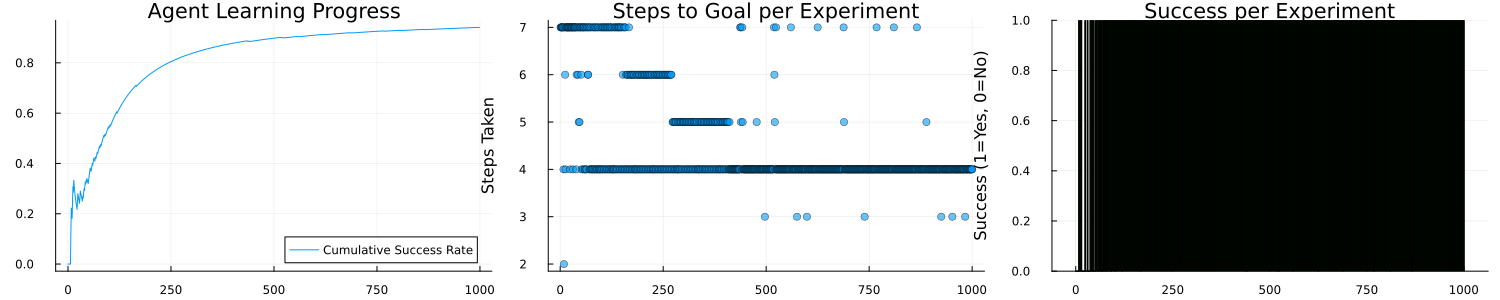

In [27]:
# Plot 1: Cumulative success rate over experiments
p_success_rate = plot(0:length(successes)-1, cumsum(successes) ./ (1:length(successes)), 
                      label="Cumulative Success Rate", ylabel="Success Rate", xlabel="Experiment",
                      title="Agent Learning Progress", legend=true, size=(600, 300))

# Plot 2: Steps taken per experiment
p_steps = scatter(1:length(steps_taken_list), steps_taken_list, 
                  title="Steps to Goal per Experiment", ylabel="Steps Taken", xlabel="Experiment",
                  label="", size=(600, 300), markersize=4, alpha=0.6)

# Plot 3: Success per experiment (binary)
p_success_per_exp = bar(1:length(successes), Int.(successes), 
                        title="Success per Experiment", ylabel="Success (1=Yes, 0=No)", xlabel="Experiment",
                        legend=false, size=(600, 300), bar_width=1, color=:green)

plot(p_success_rate, p_steps, p_success_per_exp, layout=(1, 3), size=(1500, 300))

### 7.2 Parameter Learning Visualization

Plots showing how the learned A and B tensors converge to the true generative model parameters during the experiment.


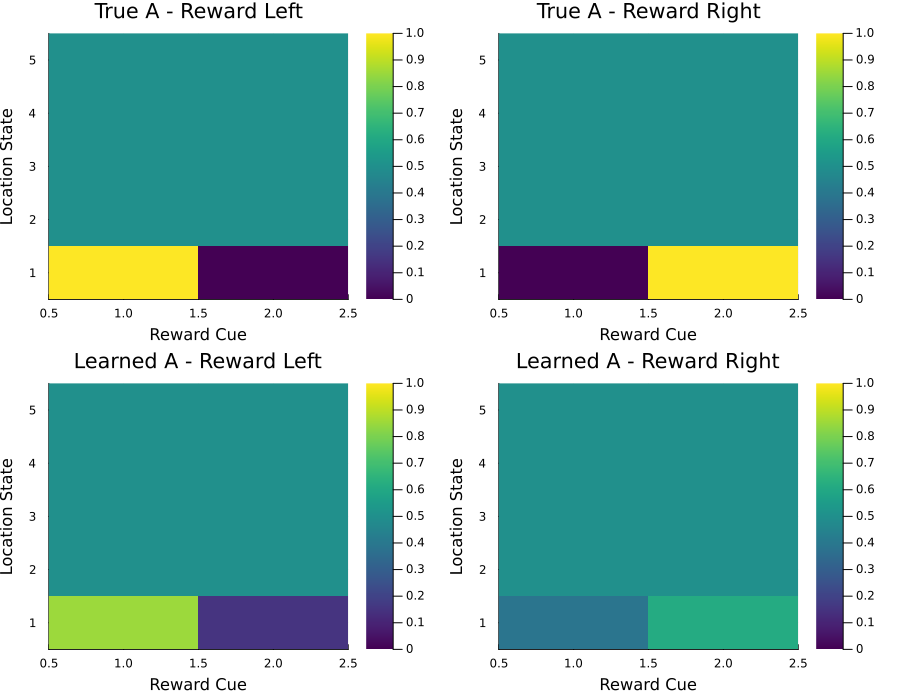

In [29]:
# Plot learned vs true A tensor (observation model) - both slices
# A tensor dimensions: (observation, location, reward_location)
# [:, :, 1] = when reward is on LEFT; [:, :, 2] = when reward is on RIGHT
A_learned_final = isempty(A_history) ? mean(p_A) : A_history[end]

# Extract both slices for true and learned tensors
pA_true_left = heatmap(A_true[:, :, 1]', 
                       title="True A - Reward Left", 
                       xlabel="Reward Cue", ylabel="Location State",
                       clims=(0, 1), color=:viridis, size=(400, 350))

pA_true_right = heatmap(A_true[:, :, 2]', 
                        title="True A - Reward Right", 
                        xlabel="Reward Cue", ylabel="Location State",
                        clims=(0, 1), color=:viridis, size=(400, 350))

pA_learned_left = heatmap(A_learned_final[:, :, 1]', 
                          title="Learned A - Reward Left", 
                          xlabel="Reward Cue", ylabel="Location State",
                          clims=(0, 1), color=:viridis, size=(400, 350))

pA_learned_right = heatmap(A_learned_final[:, :, 2]', 
                           title="Learned A - Reward Right", 
                           xlabel="Reward Cue", ylabel="Location State",
                           clims=(0, 1), color=:viridis, size=(400, 350))

plot(pA_true_left, pA_true_right, pA_learned_left, pA_learned_right, 
     layout=(2, 2), size=(900, 700))


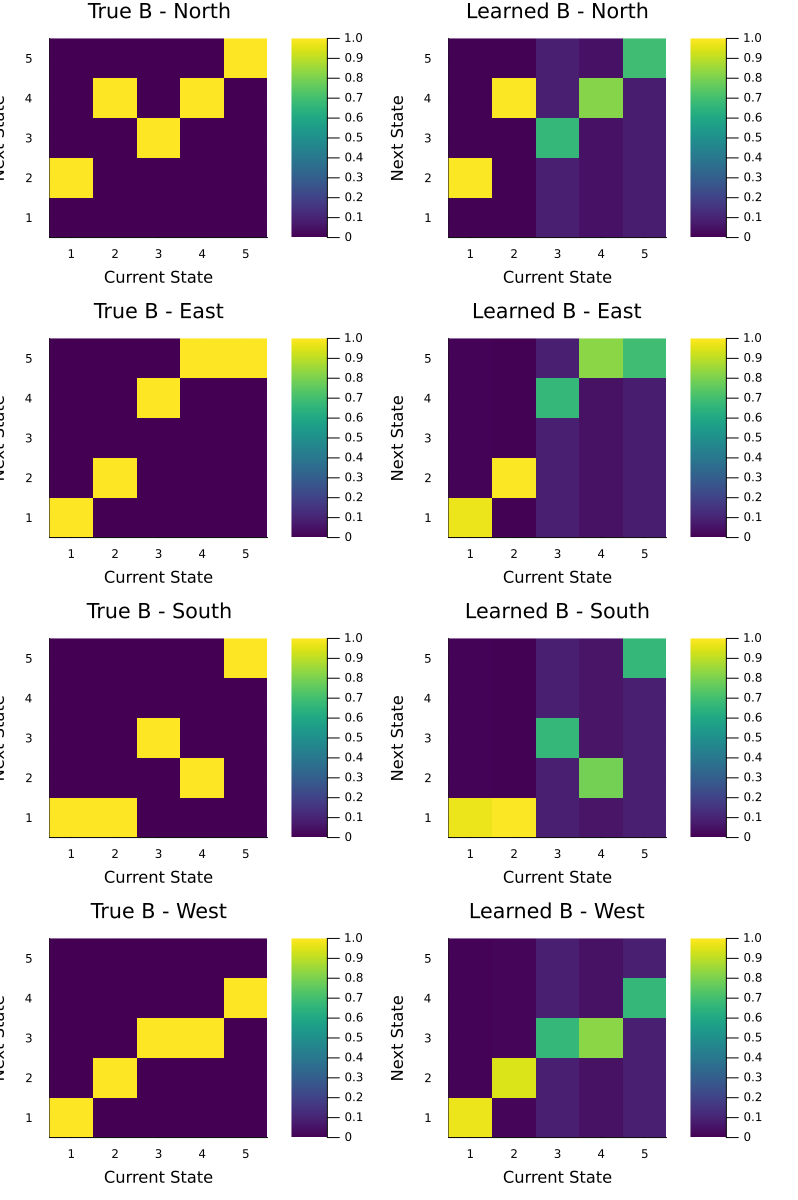

In [30]:
# Plot learned vs true B tensor (transition model) - all 4 actions
# B tensor dimensions: (next_state, current_state, action)
B_learned_final = isempty(B_history) ? mean(p_B) : B_history[end]

# Create plots for each action
action_names = ["North", "East", "South", "West"]
plots_B = []

for action_idx in 1:4
    B_true_action = B_true[:, :, action_idx]
    B_learned_action = B_learned_final[:, :, action_idx]
    
    p_true = heatmap(B_true_action, 
                     title="True B - $(action_names[action_idx])", 
                     xlabel="Current State", ylabel="Next State",
                     clims=(0, 1), color=:viridis, size=(350, 300))
    
    p_learned = heatmap(B_learned_action, 
                        title="Learned B - $(action_names[action_idx])", 
                        xlabel="Current State", ylabel="Next State",
                        clims=(0, 1), color=:viridis, size=(350, 300))
    
    push!(plots_B, p_true)
    push!(plots_B, p_learned)
end

plot(plots_B..., layout=(4, 2), size=(800, 1200))


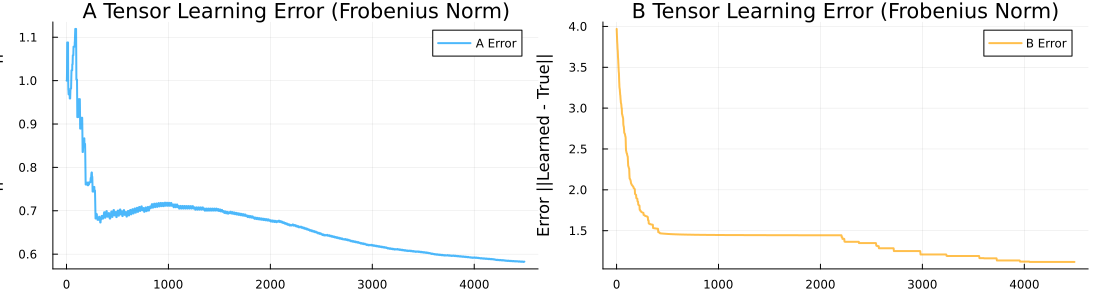

In [37]:
# Plot parameter learning errors over time
# Group errors by episode to show learning progress

if !isempty(A_error) && !isempty(B_error)
    episode_boundaries = cumsum(episode_lengths)
    
    # A tensor error plot
    p_A_error = plot(1:length(A_error), A_error,
                     title="A Tensor Learning Error (Frobenius Norm)", 
                     xlabel="Training Step", ylabel="Error ||Learned - True||",
                     label="A Error", linewidth=2, legend=true, 
                     size=(500, 300), alpha=0.7)
    
    # # Add vertical lines at episode boundaries
    # for boundary in episode_boundaries[1:end-1]
    #     vline!(p_A_error, [boundary], label="", color=:red, alpha=0.3, linestyle=:dash)
    # end
    
    # B tensor error plot
    p_B_error = plot(1:length(B_error), B_error,
                     title="B Tensor Learning Error (Frobenius Norm)", 
                     xlabel="Training Step", ylabel="Error ||Learned - True||",
                     label="B Error", linewidth=2, legend=true,
                     size=(500, 300), alpha=0.7, color=:orange)
    
    # # Add vertical lines at episode boundaries
    # for boundary in episode_boundaries[1:end-1]
    #     vline!(p_B_error, [boundary], label="", color=:red, alpha=0.3, linestyle=:dash)
    # end
    
    plot(p_A_error, p_B_error, layout=(1, 2), size=(1100, 300))
else
    println("No parameter error data collected. Ensure track_params=true was used.")
end



=== Parameter Learning Statistics ===

A Tensor (Observation Model):
  Initial Error: 1.0
  Final Error: 0.5827667358837676
  Error Reduction: 41.72332641162324%

B Tensor (Transition Model):
  Initial Error: 3.9693268390946965
  Final Error: 1.117534937779249
  Error Reduction: 71.84573145319193%

Average Error per Episode:
  A Tensor: 0.6580437390625878 ± 0.07281728578626587
  B Tensor: 1.3533658332631977 ± 0.2813192656779918


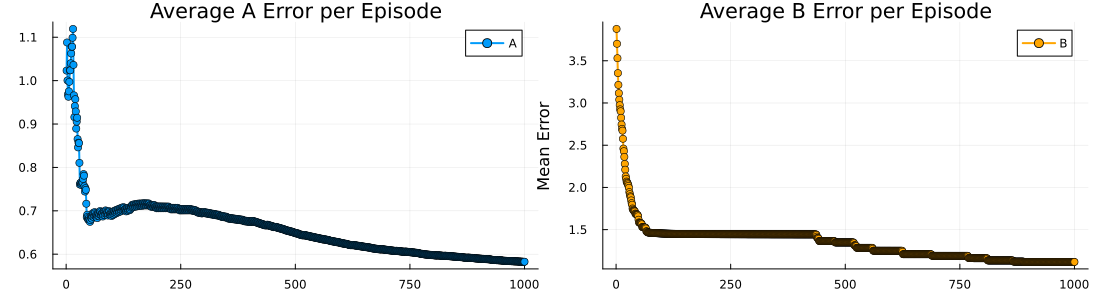

In [32]:
# Parameter Learning Statistics

if !isempty(A_error) && !isempty(B_error)
    println("\n=== Parameter Learning Statistics ===")
    println("\nA Tensor (Observation Model):")
    println("  Initial Error: $(A_error[1])")
    println("  Final Error: $(A_error[end])")
    println("  Error Reduction: $(100 * (1 - A_error[end]/A_error[1]))%")
    
    println("\nB Tensor (Transition Model):")
    println("  Initial Error: $(B_error[1])")
    println("  Final Error: $(B_error[end])")
    println("  Error Reduction: $(100 * (1 - B_error[end]/B_error[1]))%")
    
    # Calculate average errors per episode
    episode_A_errors = Float64[]
    episode_B_errors = Float64[]
    start_idx = 1
    
    for (ep_idx, ep_length) in enumerate(episode_lengths)
        end_idx = start_idx + ep_length - 1
        if end_idx <= length(A_error)
            push!(episode_A_errors, mean(A_error[start_idx:end_idx]))
            push!(episode_B_errors, mean(B_error[start_idx:end_idx]))
        end
        start_idx = end_idx + 1
    end
    
    println("\nAverage Error per Episode:")
    println("  A Tensor: $(mean(episode_A_errors)) ± $(std(episode_A_errors))")
    println("  B Tensor: $(mean(episode_B_errors)) ± $(std(episode_B_errors))")
    
    # Plot average errors per episode
    p_episode_A = plot(1:length(episode_A_errors), episode_A_errors,
                       title="Average A Error per Episode", 
                       xlabel="Episode", ylabel="Mean Error",
                       label="A", linewidth=2, marker=:circle, size=(500, 300))
    
    p_episode_B = plot(1:length(episode_B_errors), episode_B_errors,
                       title="Average B Error per Episode", 
                       xlabel="Episode", ylabel="Mean Error",
                       label="B", linewidth=2, marker=:circle, color=:orange, size=(500, 300))
    
    plot(p_episode_A, p_episode_B, layout=(1, 2), size=(1100, 300))
else
    println("No parameter error data to analyze.")
end


### 7.3 Sample Episode Trajectory

Let's visualize a sample episode to see the agent's decision-making process in the T-maze.

In [42]:
"""
Load and display experiment results from a saved JLD2 file.
"""
function load_experiment_results(filepath::String)
    data = load(filepath)["results"]  # Extract from "results" key
    
    println("\n" * "="^50)
    println("EXPERIMENT RESULTS: $(data["timestamp"])")
    println("="^50)
    println("Agent Type: $(data["agent_type"])")
    println("Number of Experiments: $(data["n_experiments"])")
    println("Success Rate: $(mean(data["successes"]) * 100)%")
    println("Average Steps: $(mean(data["steps_taken_list"]))")
    println("Steps Range: $(minimum(data["steps_taken_list"])) - $(maximum(data["steps_taken_list"]))")
    println("A Tensor Error: $(data["A_error"][end]) (initial: $(data["A_error"][1]))")
    println("B Tensor Error: $(data["B_error"][end]) (initial: $(data["B_error"][1]))")
    println("="^50 * "\n")
    
    return data
end

"""
List all saved experiment files in the results directory.
"""
function list_saved_experiments()
    results_dir = "data/results"
    if !isdir(results_dir)
        println("No results directory found.")
        return String[]
    end
    
    files = filter(f -> endswith(f, ".jld2"), readdir(results_dir))
    if isempty(files)
        println("No saved experiment files found.")
        return String[]
    end
    
    println("\nSaved Experiment Files:")
    println("-" * 30)
    for (i, file) in enumerate(sort(files, rev=true))
        filepath = joinpath(results_dir, file)
        filesize_mb = filesize(filepath) / (1024^2)
        println("$i. $file ($(round(filesize_mb; digits=2)) MB)")
    end
    println("-" * 30 * "\n")
    
    return files
end

# Example usage:
# files = list_saved_experiments()
# if !isempty(files)
#     data = load_experiment_results(joinpath("data/results", files[1]))
# end

list_saved_experiments

## 8 · Saving and Loading Results

The code above automatically saves all experiment results to `data/results/` with a timestamped filename. This section shows how to load and work with saved data.


In [44]:
using JLD2, Dates

# Create results directory if it doesn't exist
results_dir = "data/results"
mkpath(results_dir)

# Create filename with timestamp
timestamp = Dates.format(now(), "yyyy-mm-dd_HH-MM-SS")
filename = joinpath(results_dir, "tmaze_expamb_experiments_$(timestamp).jld2")

# Prepare data dictionary
results_data = Dict(
    "successes" => successes,
    "steps_taken_list" => steps_taken_list,
    "reward_locations" => reward_locations,
    "A_error" => A_error,
    "B_error" => B_error,
    "episode_lengths" => episode_lengths,
    "n_experiments" => n_experiments,
    "config" => config_exp,
    "A_true" => A_true,
    "B_true" => B_true,
    "final_A" => mean(p_A),
    "final_B" => mean(p_B),
    "timestamp" => timestamp,
    "agent_type" => "Exploration-Ambiguity"
)

# Save to JLD2 file (save entire dict under "results" key)
jldsave(filename; results=results_data)
println("\n✓ Results saved to: $filename")
println("  Success rate: $(sum(successes)/length(successes)*100)%")
println("  Experiments: $(n_experiments)")
println("  Total data points: $(length(A_error))")


✓ Results saved to: data/results\tmaze_expamb_experiments_2026-04-20_22-50-04.jld2
  Success rate: 94.1%
  Experiments: 1000
  Total data points: 4492


Recording T-Maze episode (Reward: right) to sample_tmaze_trajectory.gif...


[ Info: Saved animation to c:\Users\BMW\Documents\activeInference\rxinfer\EFEasVI_parameters\sample_tmaze_trajectory.gif


Plots.AnimatedGif("c:\\Users\\BMW\\Documents\\activeInference\\rxinfer\\EFEasVI_parameters\\sample_tmaze_trajectory.gif")
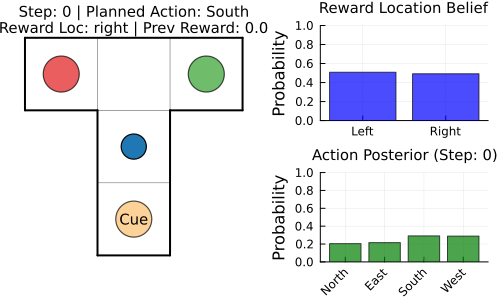

In [35]:
config_sample = (
    time_horizon = 6,
    n_iterations = 5,
    wait_time    = 0.2,
    seed         = 54
)

run_and_record_tmaze_gif(
    efe_tmaze_agent,
    tensors,
    config_sample,
    config_sample.seed,
    initialization_fn = efe_tmaze_agent_initialization,
    filename = "sample_tmaze_trajectory.gif"
)

The animation below shows a representative episode where the agent navigates the T-maze using EFE-based planning:

![](sample_tmaze_trajectory.gif)

![](tmaze_agent.gif)

## 8 · Summary

### 8.1 What did the epistemic priors actually do?

The main contribution of this paper is to implement the theoretical work outlined by deVries et al. with parameter learning. Exploring and Exploiting an environment efficiently to learn the rules as fast as possible to maximize reward. 
The paper shows that the implementation is superior to KL-control agents, with no epistemic priors and a uniform prior over actions.

### 8.2 Scalability

Traditional EFE evaluation scales as $|\mathcal{U}|^T$. The message-passing approach scales *linearly* in $T$ and $|\mathcal{U}|$ because each factor node only communicates with its direct neighbours.
The given appraoch needs to be further evaluated in higher dimensional environments, where joint learning gets even more difficult.

### 8.3 Limitations and open questions

- The $D_{KL}$ terms would need to propagate uncertainty about learning the parameters into the future. This is currently not implemented and limits longer time-horizon planning. Where the novelty term is calculated based on the agents current beliefs about the parameters.
- The epistemic priors are defined in closed form but their iterative **online update** between VMP iterations in a streaming setting requires further elaboration.

### 8.4 Further reading

- [Parameter Learning in continous autoregressive models with Active Inference](https://pure.tue.nl/ws/portalfiles/portal/386544975/2025_EIML.pdf)
- [Stochastic Maze - EFE as VI: without parameter learning](https://examples.rxinfer.com/categories/advanced_examples/efe_minimization_via_message_passing)
- [Paper 1 — EFE-based Planning as Variational Inference](https://arxiv.org/abs/2504.14898)
- [Paper 2 — A Message Passing Realization of EFE Minimization](https://arxiv.org/abs/2508.02197)
- [Active Inference is a Subtype of Variational Inference](https://arxiv.org/abs/2511.18955)